# Google Trends revisited: the API - Lane A (you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Yesterday `pytrends` gave you 429s and numbers that moved
between pulls. Today we use the **Google Trends API**: same 0-100 signal, reliable and
reproducible.

First, in the **terminal**: `source scripts/unlock-gt-api-key.sh` (Google Trends passcode),
then restart the kernel so it sees `GT_API`.

**Quota: 1,000 requests/day for the whole room, health topics only.**


## Step 0: build the API helper

> *Write `gt_api_fetch(terms, geo, start, end)` that calls*
> *`https://www.googleapis.com/trends/v1beta/graph` with query parameters `key`, repeated*
> *`terms`, `restrictions.geo`, `restrictions.startDate`, `restrictions.endDate` (dates are*
> *YYYY-MM). Read the key from the GT_API environment variable, never hardcode it. Parse*
> *`lines[].points[]` into a tidy DataFrame: a date column plus one column per term.*


In [1]:
import json
import os
import urllib.parse
import urllib.request

import pandas as pd


def gt_api_fetch(terms, geo, start, end):
    """Fetch Google Trends series into a tidy date-by-term DataFrame."""
    if isinstance(terms, str):
        terms = [terms]

    key = os.environ.get("GT_API")
    if not key:
        raise RuntimeError("GT_API is not set; source the key script and restart the kernel.")

    params = [("key", key)]
    params.extend(("terms", term) for term in terms)
    params.extend([
        ("restrictions.geo", geo),
        ("restrictions.startDate", start),
        ("restrictions.endDate", end),
    ])
    url = "https://www.googleapis.com/trends/v1beta/graph?" + urllib.parse.urlencode(params)

    with urllib.request.urlopen(url, timeout=45) as response:
        payload = json.load(response)

    frames = []
    for line in payload.get("lines", []):
        term = line.get("term", "term")
        points = line.get("points", [])
        frame = pd.DataFrame(points)[["date", "value"]].rename(columns={"value": term})
        frame["date"] = pd.to_datetime(frame["date"])
        frames.append(frame.set_index("date"))

    if not frames:
        raise RuntimeError("The Trends API response contained no lines.")

    return pd.concat(frames, axis=1).reset_index().sort_values("date").reset_index(drop=True)


## Step 1: pull yesterday's dengue signal from the API

> *Pull 'dengue', 'sintomas de dengue' and 'mosquito' for Mexico (geo=MX) since 2021-07.*
> *Plot them, and report how many points you got and whether they are weekly or monthly.*
> *If the key is missing, fall back to ../data/gt_api_dengue_mx_cached.csv.*

**Your check:** does the last point land near today, and do the peaks match the dengue
season you saw yesterday?


API unavailable (RuntimeError): GT_API is not set; source the key script and restart the kernel.
cached snapshot: 265 points; weekly data


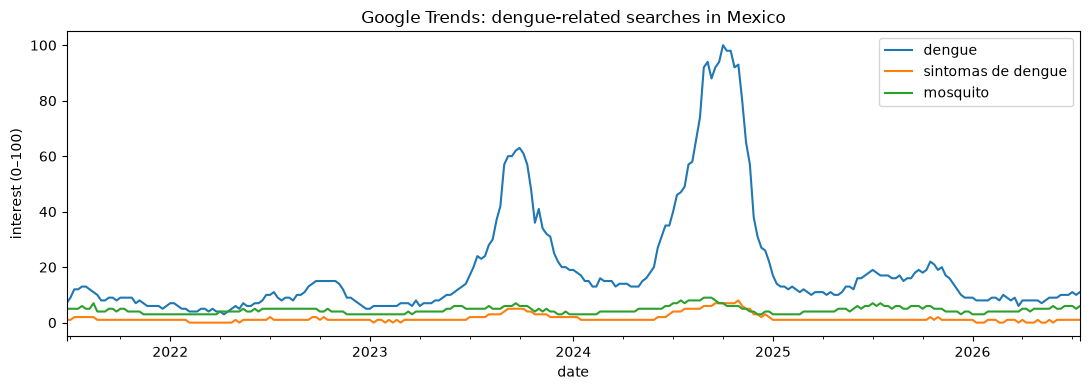

In [2]:
import matplotlib.pyplot as plt

terms = ['dengue', 'sintomas de dengue', 'mosquito']
try:
    dengue = gt_api_fetch(
        terms, geo='MX', start='2021-07',
        end=pd.Timestamp.today().strftime('%Y-%m'),
    )
    source = 'live API'
except Exception as error:
    print(f'API unavailable ({type(error).__name__}): {error}')
    dengue = pd.read_csv('../data/gt_api_dengue_mx_cached.csv', parse_dates=['date'])
    source = 'cached snapshot'

cadence_days = dengue['date'].sort_values().diff().dt.days.median()
cadence = 'weekly' if cadence_days <= 10 else 'monthly'
print(f'{source}: {len(dengue)} points; {cadence} data')

ax = dengue.plot(x='date', y=terms, figsize=(11, 4))
ax.set(title='Google Trends: dengue-related searches in Mexico',
       xlabel='date', ylabel='interest (0–100)')
plt.tight_layout()
plt.show()


## Step 2: prove it is reproducible

> *Pull the same series twice and check whether the values are identical.*

**Why it matters:** `pytrends` reads a sampled endpoint, so repeat pulls disagree. The API
is deterministic, which is what makes your analysis reproducible.


In [6]:
end_date = pd.Timestamp.today().strftime('%Y-%m')
try:
    first_pull = gt_api_fetch(terms, geo='MX', start='2021-07', end=end_date)
    second_pull = gt_api_fetch(terms, geo='MX', start='2021-07', end=end_date)
    identical = first_pull.equals(second_pull)
    print(f'Two API pulls identical? {identical}')
except Exception as error:
    print(f'Live reproducibility check unavailable ({type(error).__name__}): {error}')


Live reproducibility check unavailable (RuntimeError): GT_API is not set; source the key script and restart the kernel.


## Step 3: term vs topic across countries

> *For each of US, FR, IT and MX, pull the term 'flu' and the topic '/m/0cycc' (Influenza)*
> *in one call since 2022-01. Tabulate the max and mean of each per country, and draw a*
> *2x2 panel comparing the two series in each country.*

**What you should see:** the English term is nearly silent outside the US while the topic
tracks the flu season everywhere, because it covers *grippe*, *influenza* and *gripe*.
That is why the multi-country work later today uses topics.


In [ ]:
# Agent's term-vs-topic comparison:


## Step 4: reflect, then move on

- Same signal as yesterday, but no 429s and no drift between runs.
- Topics make one query work across languages.
- Unchanged: Google Trends is **attention**, not infection, and small places return zeros.

**Next:** streams that fail differently, Wikipedia (`01_...`) and wastewater (`02_...`).
